# Insights on Multi-Family Sales in Chicago
### 10 Questions for a Chicago Real-Estate Trivia Night - Multi-Family Companion

The two-to-four-flat market - Chicago's classic small apartment buildings. MF lives
in the **same parquet as single-family** (`meta_modeling_group == 'MF'`) with full
characteristics, so this companion gets the **full analysis, $/sqft included** - just
`K.MF` instead of `K.SF`. Compute in `analysis/sales_descriptives.py`, renderers in
`viz/charts.py` (**entity = orange, individual = blue** wherever the two are split).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import constants as K
from chicago_housing.data import wrangling
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

### Setup - the clean multi-family sample

Chicago + MF + 2022-25, drop multi-card / prorated and non-arm's-length. The one-call
helper reads the `K.MF` config (same parquet as SF, `MF` modeling group, 3-side N/W/S
map). The Loop's ~2 MF sales fall outside the 3-side scheme and are dropped so every
tally reconciles.

In [2]:
enriched = wrangling.load_sales_sample(K.MF)
print("clean multi-family sample:", enriched.shape)

scope_filter [mf]:  405,195 ->   19,223 rows


apply_drop_policy: 19,223 -> 17,662
  statutory (PTAX/family): 981
  below $10,000 floor:    0
  entity + price-corrob.:  785
dropped 6 unmapped / no-geo rows
add_region [mf]: {'North': 5899, 'West': 4845, 'South': 6912}
clean multi-family sample: (17656, 29)


## First, the lay of the land - the two-flat belt

Multi-family flips single-family's geography toward the middle: sales split **South
39% / North 33% / West 28%** - far more even than single-family (54/37/9). The
two-to-four-flat is a **West- and South-Side** staple in a way the single-family
market never was. Same three sides as the SF piece (K.MF reuses the N/W/S map).

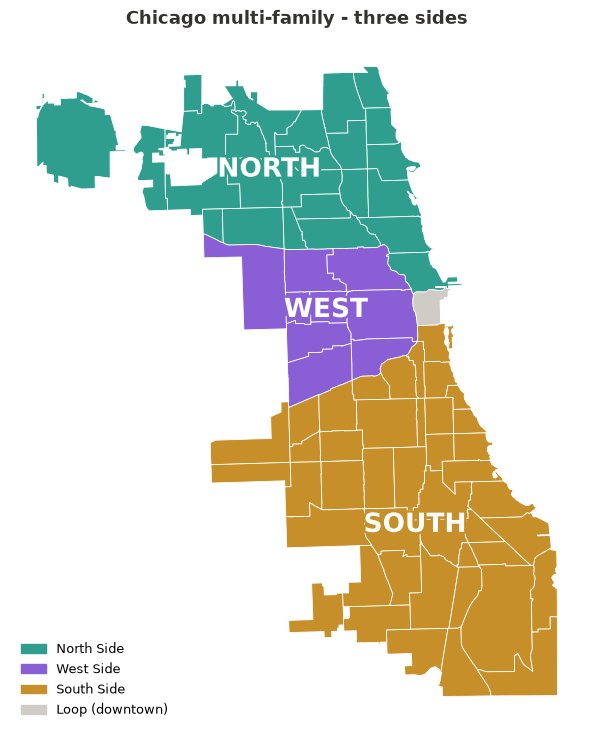

In [3]:
maps.region_map_static(K.MF, title="Chicago multi-family - three sides")
plt.show()

maps.region_map(enriched, K.MF, sales_label="MF sales 22-25:").save("mf_region_map.html")